In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

First, you need to upload the CSV file from your local machine to the Colab environment. You can use the `files.upload()` function from `google.colab` for this.

In [2]:
from google.colab import files
import io

uploaded = files.upload()

# Assuming you upload a file named 'your_file_name.csv'
# You will need to replace 'your_file_name.csv' with the actual name of your uploaded file.

Saving Twitter Analysis.csv to Twitter Analysis.csv


Once the file is uploaded, you can read it into a pandas DataFrame. Make sure to replace `'your_file_name.csv'` with the exact name of the file you uploaded.

In [3]:
# Get the name of the uploaded file(s)
# This assumes only one file is uploaded. If multiple, you'll need to choose the correct one.
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  truthseeker_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first few rows of the DataFrame, shape and headers
#display(truthseeker_df.head())
print(truthseeker_df.shape)

# print(truthseeker_df['tweet'][0])
print(truthseeker_df.info()) # print df info

User uploaded file "Twitter Analysis.csv"
(134198, 64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 64 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unnamed: 0              134198 non-null  int64  
 1   majority_target         134198 non-null  bool   
 2   statement               134198 non-null  object 
 3   BinaryNumTarget         134198 non-null  float64
 4   tweet                   134198 non-null  object 
 5   followers_count         134198 non-null  float64
 6   friends_count           134198 non-null  float64
 7   favourites_count        134198 non-null  float64
 8   statuses_count          134198 non-null  float64
 9   listed_count            134198 non-null  float64
 10  following               134198 non-null  float64
 11  embeddings              134198 non-null  object 
 12  BotScore                134198 non-null  float64
 13  BotScoreBinary     

### 1. Data Analysis by `majority_target`
Let's analyze the data by splitting it based on the `majority_target` column and then calculating descriptive statistics for other features.

In [4]:
import numpy as np

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Get all numeric columns in the DataFrame
numeric_cols = truthseeker_df.select_dtypes(include=np.number).columns.tolist()

# Define the start and end columns for the desired range
start_col = 'followers_count'
end_col = 'short_word_freq'

# Filter numeric columns to be within the specified range
cols_to_agg = []
start_found = False
for col in numeric_cols:
    if col == start_col:
        start_found = True
    if start_found:
        cols_to_agg.append(col)
    if col == end_col:
        break

aggregation_dict = {}
for col in cols_to_agg:
    if col == 'embeddings': # Exclude 'embeddings' as it's not a direct numerical feature despite showing up in select_dtypes sometimes
        continue
    aggregation_dict[f'mean_{col}'] = (col, 'mean')
    aggregation_dict[f'median_{col}'] = (col, 'median')

grouped_data = truthseeker_df.groupby('majority_target').agg(**aggregation_dict)
display(grouped_data)

# print('\nDetailed statistics for False majority_target:')
# display(truthseeker_df[truthseeker_df['majority_target'] == False][['friends_count', 'capitals', 'followers_count', 'Word count']].describe())

# print('\nDetailed statistics for True majority_target:')
# display(truthseeker_df[truthseeker_df['majority_target'] == True][['friends_count', 'capitals', 'followers_count', 'Word count']].describe())

,mean_followers_count,median_followers_count,mean_friends_count,median_friends_count,mean_favourites_count,median_favourites_count,mean_statuses_count,median_statuses_count,mean_listed_count,median_listed_count,mean_following,median_following,mean_BotScore,median_BotScore,mean_BotScoreBinary,median_BotScoreBinary,mean_cred,median_cred,mean_normalize_influence,median_normalize_influence,mean_mentions,median_mentions,mean_quotes,median_quotes,mean_replies,median_replies,mean_retweets,median_retweets,mean_favourites,median_favourites,mean_hashtags,median_hashtags,mean_URLs,median_URLs,mean_unique_count,median_unique_count,mean_total_count,median_total_count,mean_ORG_percentage,median_ORG_percentage,mean_NORP_percentage,median_NORP_percentage,mean_GPE_percentage,median_GPE_percentage,mean_PERSON_percentage,median_PERSON_percentage,mean_MONEY_percentage,median_MONEY_percentage,mean_DATE_percentage,median_DATE_percentage,mean_CARDINAL_percentage,median_CARDINAL_percentage,mean_PERCENT_percentage,median_PERCENT_percentage,mean_ORDINAL_percentage,median_ORDINAL_percentage,mean_FAC_percentage,median_FAC_percentage,mean_LAW_percentage,median_LAW_percentage,mean_PRODUCT_percentage,median_PRODUCT_percentage,mean_EVENT_percentage,median_EVENT_percentage,mean_TIME_percentage,median_TIME_percentage,mean_LOC_percentage,median_LOC_percentage,mean_WORK_OF_ART_percentage,median_WORK_OF_ART_percentage,mean_QUANTITY_percentage,median_QUANTITY_percentage,mean_LANGUAGE_percentage,median_LANGUAGE_percentage,mean_Word count,median_Word count,mean_Max word length,median_Max word length,mean_Min word length,median_Min word length,mean_Average word length,median_Average word length,mean_present_verbs,median_present_verbs,mean_past_verbs,median_past_verbs,mean_adjectives,median_adjectives,mean_adverbs,median_adverbs,mean_adpositions,median_adpositions,mean_pronouns,median_pronouns,mean_TOs,median_TOs,mean_determiners,median_determiners,mean_conjunctions,median_conjunctions,mean_dots,median_dots,mean_exclamation,median_exclamation,mean_questions,median_questions,mean_ampersand,median_ampersand,mean_capitals,median_capitals,mean_digits,median_digits,mean_long_word_freq,median_long_word_freq,mean_short_word_freq,median_short_word_freq
majority_target,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
False,5542.774539,268.0,1692.611933,475.0,30200.992118,7637.0,28741.515051,9290.0,38.257265,1.0,0.0,0.0,0.060739,0.03,0.034257,0.0,0.380719,0.362911,0.074412,0.076450,1.452517,1.0,0.741187,0.0,2.493414,0.0,7.101115,0.0,28.395903,0.0,0.059773,0.0,0.793814,1.0,2.273657,2.0,3.347523,3.0,0.209804,0.0,0.058578,0.0,0.125621,0.0,0.253816,0.142857,0.021923,0.0,0.097282,0.0,0.077620,0.0,0.026053,0.0,0.011625,0.0,0.004115,0.0,0.003913,0.0,0.007115,0.0,0.001885,0.0,0.006515,0.0,0.009194,0.0,0.009719,0.0,0.002602,0.0,0.000273,0.0,36.094030,39.0,13.103277,13.0,1.371996,1.0,5.022437,4.914894,2.629644,2.0,1.960575,2.0,2.933924,3.0,1.648276,1.0,3.570392,3.0,1.673010,1.0,0.834005,1.0,0.144772,0.0,1.049285,1.0,2.410240,2.0,0.318418,0.0,0.339733,0.0,0.123396,0.0,14.072470,10.0,3.51709,1.0,2.281432,2.0,22.214160,22.0
True,16728.971168,452.0,2083.315199,658.0,35609.456041,9194.0,39351.777546,13000.0,106.427035,3.0,0.0,0.0,0.057562,0.03,0.030557,0.0,0.429610,0.411879,0.080739,0.082128,1.328796,1.0,0.414800,0.0,1.366659,0.0,6.270928,0.0,26.793897,0.0,0.147220,0.0,0.684656,1.0,2.452562,2.0,3.529811,3.0,0.190661,0.0,0.075763,0.0,0.146105,0.0,0.191788,0.000000,0.036711,0.0,0.107119,0.0,0.103851,0.0,0.034974,0.0,0.013196,0.0,0.002631,0.0,0.006543,0.0,0.006578,0.0,0.003288,0.0,0.004855,0.0,0.010316,0.0,0.007380,0.0,0.002201,0.0,0.001709,0.0,34.116924,36.0,13.023063,13.0,1.426194,1.0,5.088988,5.000000,2.284758,2.0,1.671958,1.0,3.129202,3.0,1.507429,1.0,3.666203,3.0,1.328318,1.0,0.745727,0.0,0.126897,0.0,0.960209,1.0,2.324404,2.0,0.203624,0.0,0.276350,0.0,0.119780,0.0,11.659172,9.0,3.59958,2.0,2.219425,2.0,20.705559,20.0


### 2. Define Features (X) and Target (y)
We will use `majority_target` as our target variable (y) and the rest of the relevant columns as features (X). We'll exclude text-based columns (`statement`, `tweet`) for this initial SVC model, as they require specialized NLP techniques.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define target (y) and features (X)
y = truthseeker_df['majority_target']

# Drop target, uneeded, and text columns for now
X = truthseeker_df.drop(columns=['majority_target', 'statement', 'tweet', 'embeddings', 'BinaryNumTarget', 'Unnamed: 0'])

# Handle potential NaN values if any (e.g., fill with mean or median)
X = X.fillna(X.mean(numeric_only=True))

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (134198, 58)
Shape of y: (134198,)


### 3. Split Data into Training and Testing Sets
We'll split the data to evaluate the model's performance on unseen data.

In [23]:
sample_fraction = 0.1 # Increase sample size to 10% (from 1%) for more data

# Sample the data before splitting
X_sample, y_sample = X.sample(frac=sample_fraction, random_state=42), y.sample(frac=sample_fraction, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (10736, 58)
X_test shape: (2684, 58)
y_train shape: (10736,)
y_test shape: (2684,)


### 4. Scale Features
SVC models are sensitive to the scale of input features, so we'll use `StandardScaler` to normalize them.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


### 5. Train and Evaluate SVC Model
Now, we'll initialize and train the Support Vector Classifier and then evaluate its performance.

In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the SVC model
# Using 'linear' kernel for potentially faster training on larger datasets, but 'rbf' is also common.
# You might need to experiment with different kernels and parameters.
svc_model = SVC(kernel='linear', random_state=42, C=1.0)

# Train the model
print("Training SVC model...")
svc_model.fit(X_train_scaled, y_train)
print("SVC model training complete.")

# Make predictions on the test set
y_pred = svc_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Training SVC model...
SVC model training complete.

Model Accuracy: 0.6151

Classification Report:
               precision    recall  f1-score   support

       False       0.61      0.59      0.60      1303
        True       0.62      0.64      0.63      1381

    accuracy                           0.62      2684
   macro avg       0.61      0.61      0.61      2684
weighted avg       0.61      0.62      0.61      2684



In [26]:
X_bert_raw = truthseeker_df['tweet']
y_bert_raw = truthseeker_df['majority_target'].astype(int)

sample_fraction = 0.1 # Increase sample size to 10% (from 1%) to match general dataset sampling
X_sample_bert, y_sample_bert = X_bert_raw.sample(frac=sample_fraction, random_state=42), y_bert_raw.sample(frac=sample_fraction, random_state=42)

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(X_sample_bert, y_sample_bert, test_size=0.2, random_state=42, stratify=y_sample_bert)

print(f"X_train_bert shape: {X_train_bert.shape}")
print(f"X_test_bert shape: {X_test_bert.shape}")
print(f"y_train_bert shape: {y_train_bert.shape}")
print(f"y_test_bert shape: {y_test_bert.shape}")

X_train_bert shape: (10736,)
X_test_bert shape: (2684,)
y_train_bert shape: (10736,)
y_test_bert shape: (2684,)


In [27]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

train_encodings = tokenizer(list(X_train_bert), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test_bert), truncation=True, padding=True, max_length=128)

print("Text data tokenized successfully.")

Text data tokenized successfully.


In [28]:
import torch

class TruthseekerDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create dataset objects
train_dataset = TruthseekerDataset(train_encodings, list(y_train_bert))
eval_dataset = TruthseekerDataset(test_encodings, list(y_test_bert))

print("PyTorch Datasets created successfully.")

PyTorch Datasets created successfully.


In [29]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer

model_bert = BertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased", num_labels=2)


training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5, # Increased epochs for more training
    per_device_train_batch_size=32, # Increased batch size for faster training
    per_device_eval_batch_size=32, # Increased batch size for faster evaluation
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    fp16=True, # Enable mixed-precision training for speed up
    push_to_hub=False
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecat

Epoch,Training Loss,Validation Loss
1,0.288170,0.321262
2,0.288107,0.264192
3,0.211350,0.260193
4,0.153331,0.291273
5,0.072921,0.311860


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1680, training_loss=0.2519832391291857, metrics={'train_runtime': 487.8058, 'train_samples_per_second': 110.044, 'train_steps_per_second': 3.444, 'total_flos': 3530950362931200.0, 'train_loss': 0.2519832391291857, 'epoch': 5.0})

In [30]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

predictions = trainer.predict(eval_dataset)

predicted_labels = np.argmax(predictions.predictions, axis=1)

true_labels = predictions.label_ids


accuracy_bert = accuracy_score(true_labels, predicted_labels)
report_bert = classification_report(true_labels, predicted_labels)

print(f"\nBERT Model Accuracy: {accuracy_bert:.4f}")
print("\nBERT Classification Report:\n", report_bert)



BERT Model Accuracy: 0.9154

BERT Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      1303
           1       0.91      0.93      0.92      1381

    accuracy                           0.92      2684
   macro avg       0.92      0.92      0.92      2684
weighted avg       0.92      0.92      0.92      2684



### 6. BERT Model Visualization: Confusion Matrix
Let's visualize the performance of the BERT model using a confusion matrix.

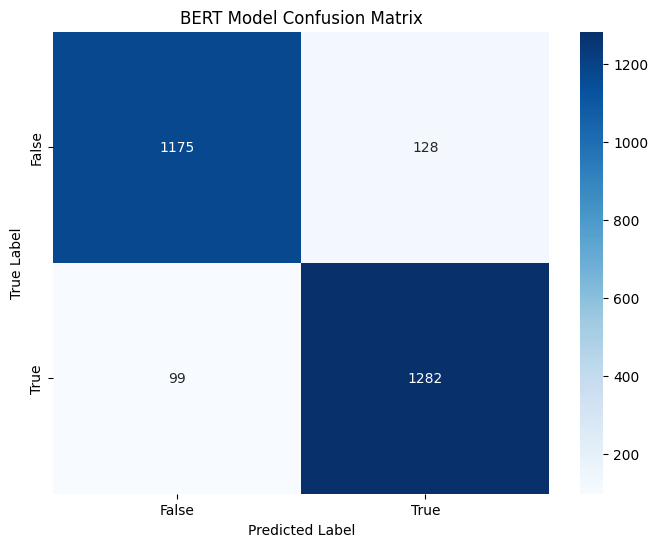

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.title('BERT Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [32]:
!pip install captum

### 7. BERT Model Feature Importance: Token Attributions

Since BERT models process text at a token level, 'feature importance' typically refers to the contribution of individual words or subwords to the model's prediction. We'll use the `Captum` library to compute Integrated Gradients, a method to attribute the model's output to its input features (tokens). We'll visualize these attributions for a sample tweet as a bar plot.

Sample Tweet: @lindsemcpherson HR 1 is illegal.  Law it is illegal for me to pay or bribe anyone to vote.  I pay taxes.  A federal employee voting and getting paid holiday time is being paid by my taxes. This means I am paying them to vote.  100% Illegal
True Label: 0
Predicted Label: 0


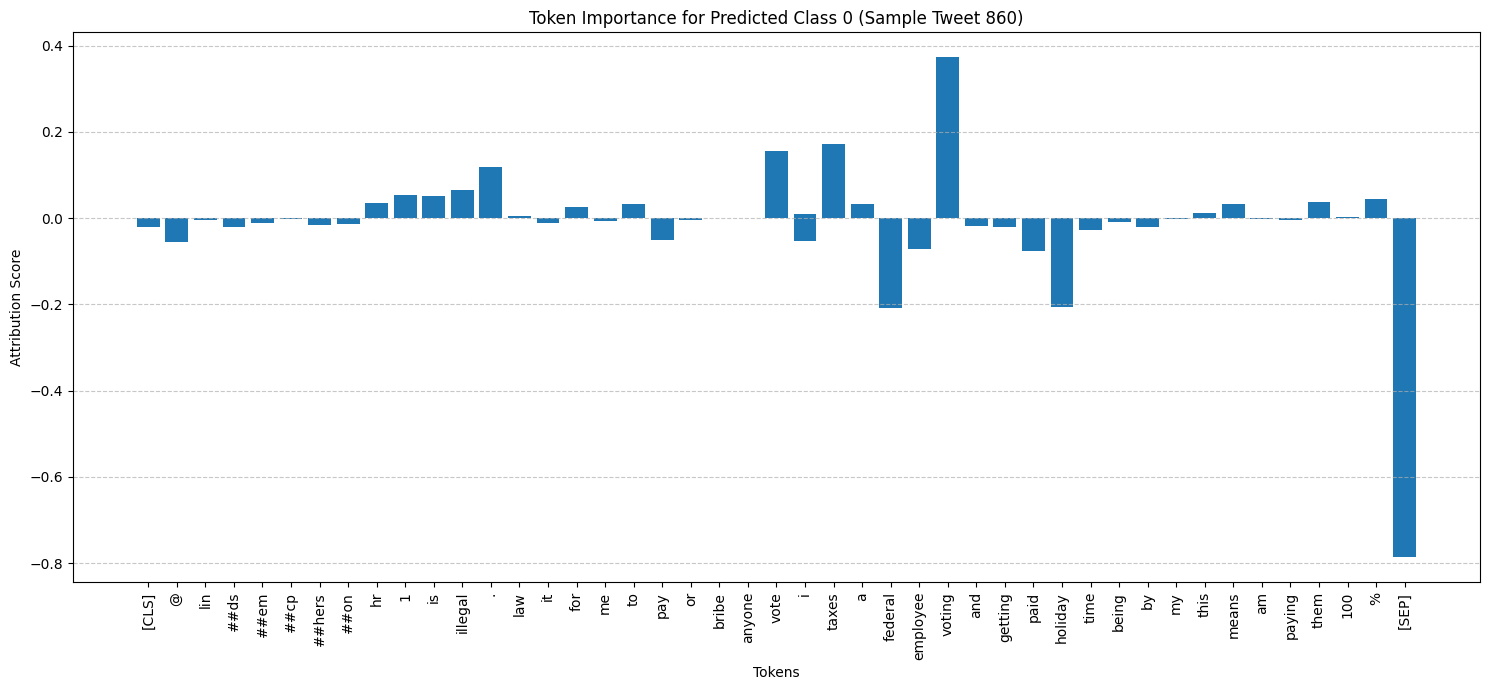

In [35]:
from captum.attr import IntegratedGradients
import torch

def predict(inputs_embeds, attention_mask):
    inputs_embeds = inputs_embeds.to(model_bert.device)
    attention_mask = attention_mask.to(model_bert.device)
    return model_bert(inputs_embeds=inputs_embeds, attention_mask=attention_mask).logits

sample_idx = np.random.randint(0, len(X_test_bert))
sample_tweet = X_test_bert.iloc[sample_idx]
sample_true_label = y_test_bert.iloc[sample_idx]

print(f"Sample Tweet: {sample_tweet}")
print(f"True Label: {sample_true_label}")

inputs_tokenized = tokenizer(sample_tweet, return_tensors='pt', truncation=True, padding=True, max_length=128)
input_ids = inputs_tokenized['input_ids']
attention_mask = inputs_tokenized['attention_mask']

with torch.no_grad():
    outputs = model_bert(input_ids.to(model_bert.device), attention_mask.to(model_bert.device))
    predicted_label = torch.argmax(outputs.logits, dim=-1).item()

print(f"Predicted Label: {predicted_label}")

word_embeddings = model_bert.bert.embeddings.word_embeddings

input_embeddings = word_embeddings(input_ids.to(model_bert.device))

ref_token_id = tokenizer.pad_token_id

ref_input_ids = torch.full_like(input_ids, ref_token_id, dtype=torch.long)

ref_input_embeddings = word_embeddings(ref_input_ids.to(model_bert.device))

ig = IntegratedGradients(predict)

attributions, delta = ig.attribute(
    inputs=input_embeddings,
    baselines=ref_input_embeddings,
    target=predicted_label,
    additional_forward_args=attention_mask.to(model_bert.device),
    return_convergence_delta=True
)

attributions = attributions.sum(dim=-1).squeeze(0)

attributions = attributions / torch.norm(attributions)
attributions = attributions.cpu().detach().numpy()

all_tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).tolist())

plt.figure(figsize=(15, 7))
plt.bar(all_tokens, attributions)
plt.xticks(rotation=90)
plt.xlabel('Tokens')
plt.ylabel('Attribution Score')
plt.title(f'Token Importance for Predicted Class {predicted_label} (Sample Tweet {sample_idx})')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

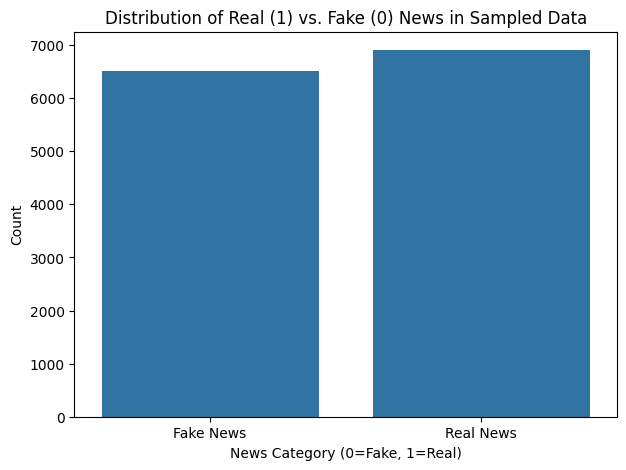

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y_sample_bert)
plt.title('Distribution of Real (1) vs. Fake (0) News in Sampled Data')
plt.xlabel('News Category (0=Fake, 1=Real)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake News', 'Real News'])
plt.show()

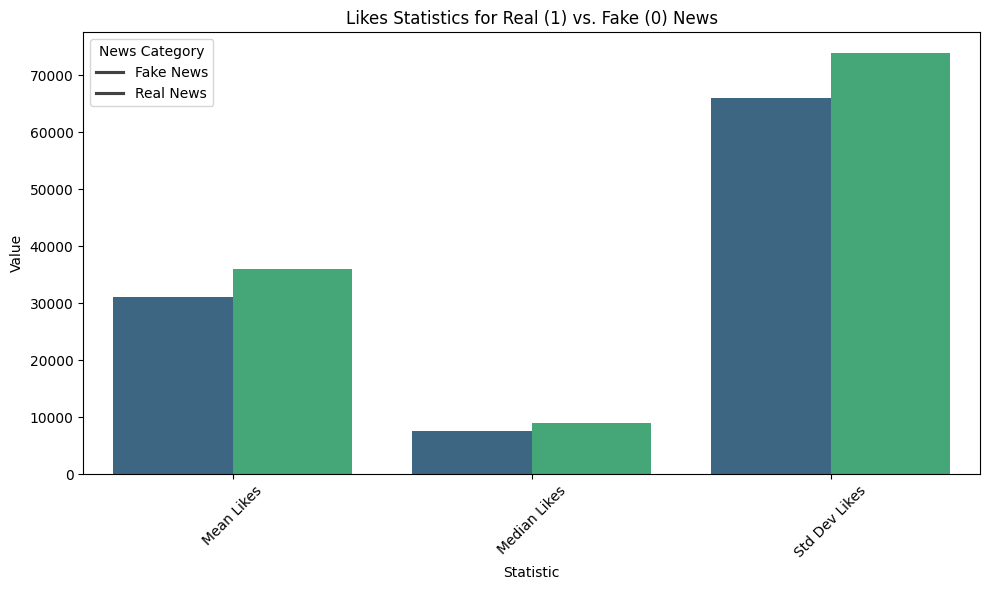

In [37]:

sampled_df_with_features = truthseeker_df.loc[y_sample_bert.index][['majority_target', 'favourites_count']]

likes_stats = sampled_df_with_features.groupby('majority_target')['favourites_count'].agg(['mean', 'median', 'std']).reset_index()
likes_stats.columns = ['majority_target', 'Mean Likes', 'Median Likes', 'Std Dev Likes']

likes_melted = likes_stats.melt(id_vars='majority_target', var_name='Statistic', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Statistic', y='Value', hue='majority_target', data=likes_melted, palette='viridis')
plt.title('Likes Statistics for Real (1) vs. Fake (0) News')
plt.xlabel('Statistic')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(title='News Category', labels=['Fake News', 'Real News'])
plt.tight_layout()
plt.show()

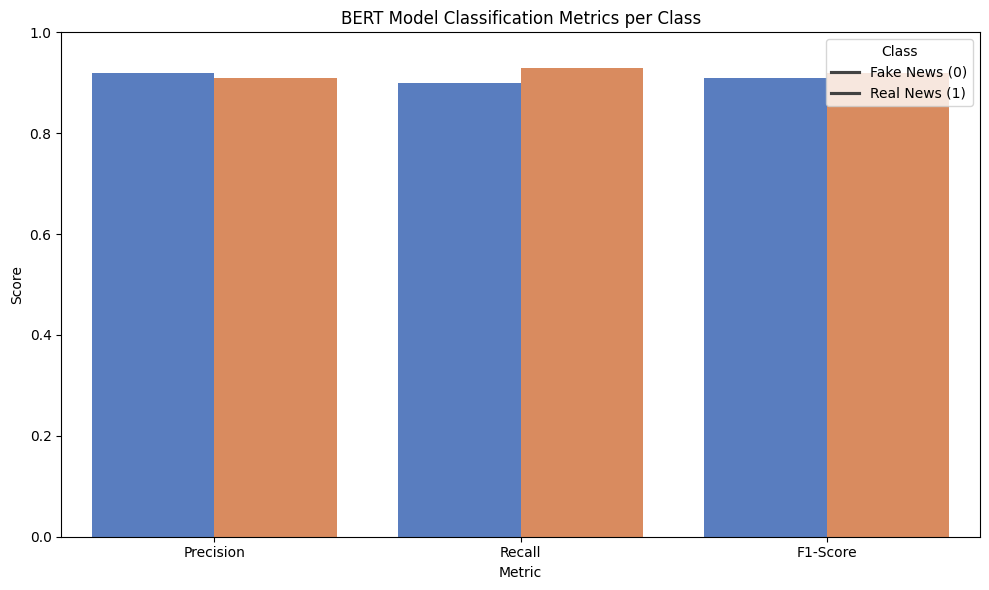

In [38]:
report_lines = report_bert.split('\n')

class_metrics = {}
for line in report_lines[2:-5]:
    parts = line.split()
    if len(parts) >= 5:
        label = parts[0]
        precision = float(parts[1])
        recall = float(parts[2])
        f1_score = float(parts[3])
        class_metrics[label] = {'Precision': precision, 'Recall': recall, 'F1-Score': f1_score}

metrics_df = pd.DataFrame.from_dict(class_metrics, orient='index')
metrics_df.index.name = 'Class'
metrics_melted = metrics_df.reset_index().melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Class', data=metrics_melted, palette='muted')
plt.title('BERT Model Classification Metrics per Class')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Class', labels=['Fake News (0)', 'Real News (1)'])
plt.tight_layout()
plt.show()

In [34]:
import torch
from transformers import AutoTokenizer, BertForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased", problem_type="multi_label_classification")

inputs = tokenizer("Hello, my dog is cute", return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits
    print(logits)

predicted_class_ids = torch.arange(0, logits.shape[-1])[torch.sigmoid(logits).squeeze(dim=0) > 0.5]
print(predicted_class_ids)

outputs = model(**inputs, labels=torch.FloatTensor([[0.0, 1.0]]))
print(outputs)

num_labels = len(model.config.id2label)
model = BertForSequenceClassification.from_pretrained(
    "google-bert/bert-base-uncased", num_labels=num_labels, problem_type="multi_label_classification"
)

labels = torch.sum(
    torch.nn.functional.one_hot(predicted_class_ids[None, :].clone(), num_classes=num_labels), dim=1
).to(torch.float)
loss = model(**inputs, labels=labels).loss
print(loss)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tensor([[0.0397, 0.3090]])
tensor([0, 1])
SequenceClassifierOutput(loss=tensor(0.6319, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), logits=tensor([[0.0397, 0.3090]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tensor(0.7164, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
